In [ ]:
import os
import torch
import numpy as np
import SimpleITK as sitk
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt

import pandas as pd
import cv2 
import torchvision.models as models
import torch.nn.init as init
import torch.nn as nn
import sys

from .models.ResLKA_Unet import ResLKA_Unet
from .models.ResNet50_Unet import Resnet50_Unet
from .loss import *
from .dataset import LiTS
from .metric import compute_scores

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
liver_seg_model = Resnet50_Unet()
checkpoint1 = torch.load("Path/to/liver_model.pt",weights_only=False, map_location=device)
liver_seg_model.load_state_dict(checkpoint1["model"])

<All keys matched successfully>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tumor_seg_model = Resnet50_Unet()
checkpoint2 = torch.load("Path/to/tumor_model.pt",weights_only=False, map_location=device)
tumor_seg_model.load_state_dict(checkpoint2["model"])

<All keys matched successfully>

In [ ]:
def infer(idx):

    img_path = f'Path/to/volume-{idx}.nii'
    target_path = f'Path/to/segmentation-{idx}.nii'

    image = sitk.ReadImage(img_path) 
    target = sitk.ReadImage(target_path) 

    image_arr = sitk.GetArrayFromImage(image)
    target_arr = sitk.GetArrayFromImage(target)

    liver_image_arr = image_arr.copy()
    liver_image_arr = np.clip(liver_image_arr, -200, 200)  
    liver_target = (target_arr > 0)

    liver_image_tensor = torch.from_numpy(liver_image_arr).unsqueeze(0).float().to(device) 
    liver_seg_model.to(device).eval() 
    with torch.no_grad(): 
        liver_pred = liver_seg_model(liver_image_tensor) 
        liver_pred = (liver_pred > 0.5).float().cpu().numpy().squeeze(0) 
        liver_pred = liver_pred.astype('uint8') 



    tumor_image_arr = image_arr.copy()
    tumor_image_arr = np.clip(tumor_image_arr, -100, 200)
    tumor_image_arr = np.where(liver_pred[0], tumor_image_arr, -1024) 

    tumor_target = (target_arr == 2)

    tumor_image_tensor = torch.from_numpy(tumor_image_arr)
    tumor_image_tensor = tumor_image_tensor.repeat(3, 1, 1)
    tumor_image_tensor = tumor_image_tensor.unsqueeze(0).float().to(device) 

    tumor_seg_model.to(device).eval() 
    with torch.no_grad(): 
        tumor_pred = tumor_seg_model(tumor_image_tensor) 
        tumor_pred = (tumor_pred > 0.55).float().cpu().numpy().squeeze(0) 
        tumor_pred = tumor_pred.astype('uint8') 
    
    return image_arr, target_arr, liver_image_arr, liver_pred, liver_target, tumor_image_arr, tumor_pred, tumor_target



In [ ]:
def plot_infer(idx):
    image_arr, target_arr, liver_image_arr, liver_pred, liver_target, tumor_image_arr, tumor_pred, tumor_target = infer(idx)

    plt.figure(figsize=(10, 10)) 
        
    plt.subplot(1, 4, 1) 
    plt.imshow(liver_image_arr[0], cmap='gray') 
    plt.title(f'CT image')
    plt.axis('off')

    plt.subplot(1, 4, 2) 
    plt.imshow(target_arr[0], cmap='gray') 
    plt.title('target')
    plt.axis('off')

    plt.subplot(1, 4, 3) 
    plt.imshow(liver_pred[0], cmap='gray') 
    plt.title('liver pred')
    plt.axis('off')

    plt.subplot(1, 4, 4) 
    plt.imshow(tumor_pred[0], cmap='gray') 
    plt.title('tumor pred')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()


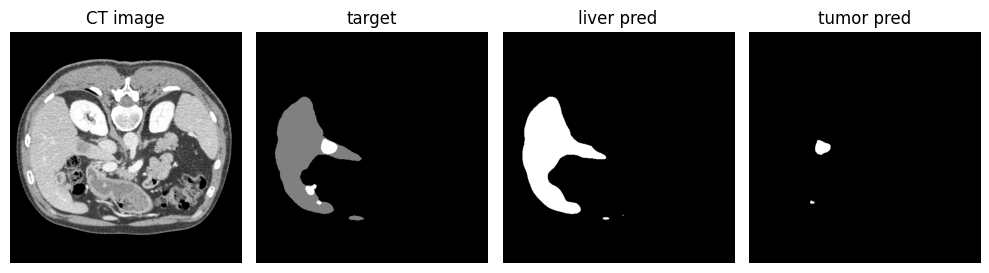

In [43]:
plot_infer(idx=1965)